# 📊 Exploratory Data Analysis:

### US Data & Business Analytics Market

**Objective:** To understand the landscape of data-focused roles in the US, identify top hiring companies, and analyze the prevalence of remote work across different analytical functions.


In [2]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading dataset from Hugging Face
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

In [3]:
# Data Cleanup

# Convert the date column to a proper datetime format so we can analyze trend over time
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# Extracting Month for seasonal trend analysis
df["job_posted_month"] = df["job_posted_date"].dt.month

# Convert the text strings in the skills column into actual Python lists
df["job_skills"] = df["job_skills"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [4]:
# Filtering the dataset entirely on the United States job market
df_US = df[df["job_country"] == "United States"].copy()

### 1. Market Overview: Top Data Roles in the US

**Objective:** To determine which data professions have the highest volume of job postings in the current US market.


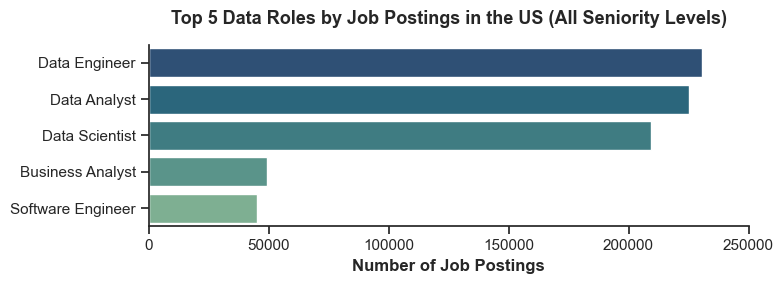

In [ ]:
# 1. Create a new column that removes the word "Senior " so that the roles group together
df["job_category"] = df["job_title_short"].str.replace("Senior ", "")

# 2. Count the top 5 grouped roles using this new column
role_counts = df["job_category"].value_counts().head(5)

# 3. Plot the findings
plt.figure(figsize=(8, 3))
sns.barplot(
    x=role_counts.values,
    y=role_counts.index,
    hue=role_counts.index,
    palette="crest_r",
    legend=False,
)
sns.despine()  # to remove the border around the plot

plt.title(
    "Top 5 Data Roles by Job Postings in the US (All Seniority Levels)",
    fontsize=13,
    weight="bold",
    pad=15,
)
plt.xlabel("Number of Job Postings", weight="bold", fontsize=12)
plt.xticks(range(0, 250001, 50000))
plt.ylabel("")
plt.tight_layout()
plt.show()

### 💡 Market Insight:

Looking at the US job market, Data Analysts, Data Engineers, and Data Scientists clearly dominate the open roles. But what really stands out is how strong and stable the Business Analyst role remains right alongside them. This proves that while companies need heavy technical skills, they are just as desperate for professionals who can translate raw data into real-world business operations.


### 2. Top Hiring Companies for Data Analysts

Focusing specifically on Data Analysts, which organizations are driving the most demand?


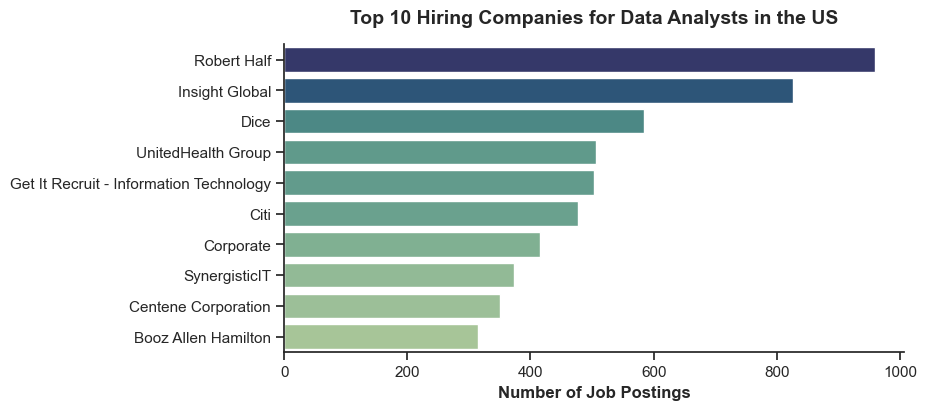

In [ ]:
# Filter the data to strictly look at Data Analyst roles
df_DA_US = df_US[df_US["job_title_short"] == "Data Analyst"].copy()

# Find the top 10 companies hiring the most Data Analysts right now
df_plot = df_DA_US["company_name"].value_counts().head(10).to_frame()

sns.set_theme(style="ticks")
plt.figure(figsize=(8, 4))
sns.barplot(
    data=df_plot,
    x="count",
    y="company_name",
    hue="count",
    palette="crest",
    legend=False,
)
sns.despine()

plt.title(
    "Top 10 Hiring Companies for Data Analysts in the US",
    weight="bold",
    fontsize=14,
    pad=15,
)
plt.xlabel("Number of Job Postings", weight="bold")
plt.ylabel("")
plt.show()

### 3. Remote Work Landscape: Data Analyst vs. Business Analyst

Hypothesis: Business Analyst roles require more on-site presence due to the operational and stakeholder-facing nature of the role compared to Data Analysts.


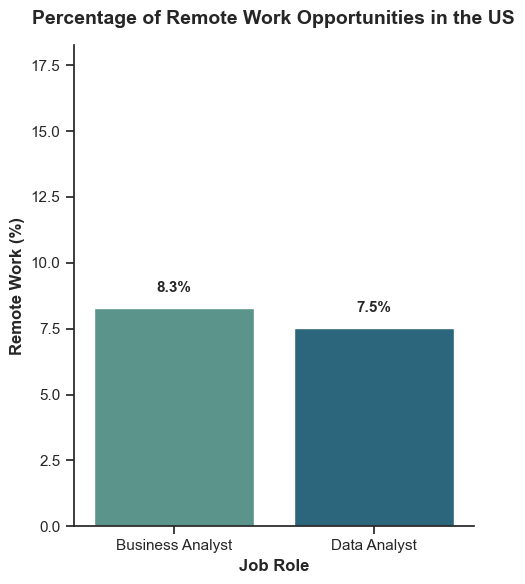

In [ ]:
# Filter for US Data Analysts and Business Analysts
roles_to_analyze = ["Data Analyst", "Business Analyst"]
df_us_roles = df_US[df_US["job_title_short"].isin(roles_to_analyze)]

# Calculate percentage of remote jobs
remote_stats = (
    df_us_roles.groupby("job_title_short")["job_work_from_home"].mean().reset_index()
)
remote_stats["job_work_from_home"] = remote_stats["job_work_from_home"] * 100

plt.figure(figsize=(5, 6))
sns.barplot(
    data=remote_stats,
    x="job_title_short",
    y="job_work_from_home",
    hue="job_title_short",
    palette="crest",
    legend=False,
)

sns.despine()
plt.title(
    "Percentage of Remote Work Opportunities in the US",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Job Role", fontsize=12, weight="bold")
plt.ylabel("Remote Work (%)", fontsize=12, weight="bold")

# Add percentage labels
for index, value in enumerate(remote_stats["job_work_from_home"]):
    plt.text(
        index,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )
plt.ylim(0, max(remote_stats["job_work_from_home"]) + 10)
plt.tight_layout()
plt.show()

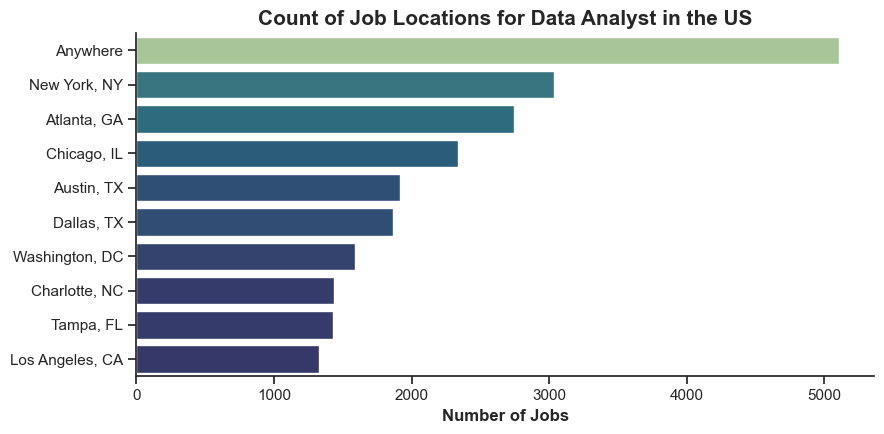

In [ ]:
# Identify the top 10 most popular job locations for Data Analysts in the US
# Using a horizontal bar chart which makes it easy to compare the volume of jobs in each area

df_plot = df_DA_US["job_location"].value_counts().head(10).to_frame().reset_index()
plt.figure(figsize=(9, 4.5))
sns.set_theme(style="ticks")
sns.barplot(
    data=df_plot,
    x="count",
    y="job_location",
    hue="count",
    palette="crest_r",
    legend=False,
)
sns.despine()

plt.title(
    "Count of Job Locations for Data Analyst in the US", weight="bold", fontsize=15
)
plt.xlabel("Number of Jobs", weight="bold", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.show()

0 job_work_from_home Work From Home Offered
1 job_no_degree_mention Degree Requirement
2 job_health_insurance Health Insurance Offered


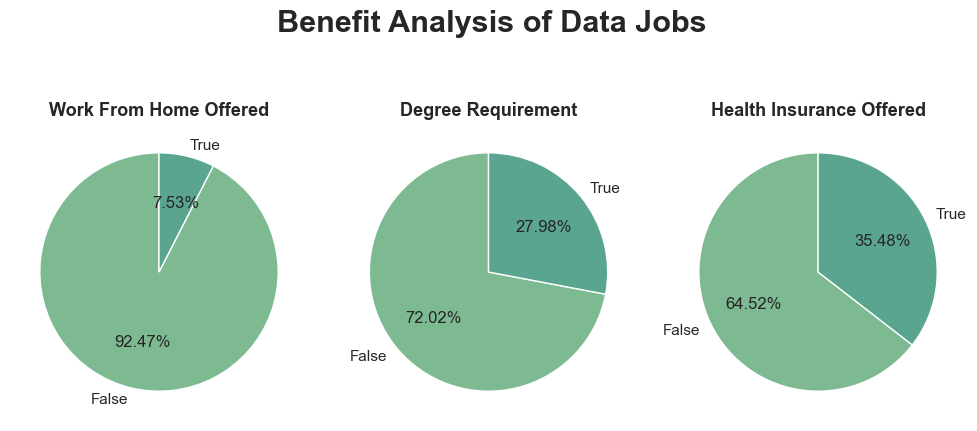

In [ ]:
# Create a dictionary to map our dataset columns to clean chart titles
dict_column = {
    "job_work_from_home": "Work From Home Offered",
    "job_no_degree_mention": "Degree Requirement",
    "job_health_insurance": "Health Insurance Offered",
}

colors = sns.color_palette("crest")
# To generate 3 pie charts side-by-side to visualize job benefits
fig, ax = plt.subplots(1, 3, figsize=(10, 5))


for i, (column, title) in enumerate(dict_column.items()):
    print(i, column, title)  # to check
    ax[i].pie(
        df_DA_US[column].value_counts(),
        labels=["False", "True"],
        startangle=90,
        autopct="%1.2f%%",
        colors=colors,
    )
    ax[i].set_title(title, fontsize=13, weight="bold")

plt.suptitle("Benefit Analysis of Data Jobs", fontsize=22, weight="bold")
plt.tight_layout()
plt.show()

### 💡 Market Insight:

Interestingly, a massive portion of Data Analyst postings do not explicitly mandate a formal degree, and nearly half offer remote work. This indicates a massive shift toward skills-based, decentralized hiring.
